In [10]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import roc_curve, roc_auc_score
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import random
import os

In [11]:
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [12]:
RUN_HYPERPARAMETER_SEARCH  = False    
RUN_FINAL_TRAINING         = False 
RUN_TEST_EVALUATION        = True     

# Best hyperparameters FOUND AFTER tuning:
BEST_DROPOUT     = 0.01
BEST_BATCH_SIZE  = 32
BEST_NUM_EPOCHS  = 50

## Loading data

In [13]:
train_data = torch.load("data/train_embeddings.pt")
val_data = torch.load("data/val_embeddings.pt")
int_test_data = torch.load("data/test_embeddings.pt")
ext_test_data = torch.load("data/ext_test_embeddings.pt")

C:\Users\Hilarius\AppData\Local\Temp\ipykernel_4840\1244337116.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_data = torch.load("data/train_embeddings.pt")
C:\Use

## Defining model

In [14]:
class CrossSeqTransformer(nn.Module):
    def __init__(self, vocab_size=6, d_model=128, nhead=8,
                  num_encoder_layers=3, num_decoder_layers=3,
                  max_len=47, dropout=0.1, dg_embedding_dim=16):
         super().__init__()
         
         # Token embeddings
         self.token_embed = nn.Embedding(vocab_size, d_model)
         self.pos_embed = nn.Embedding(max_len, d_model)
         
         # Transformer (encoder-decoder)
         self.transformer = nn.Transformer(
             d_model=d_model,
             nhead=nhead,
             num_encoder_layers=num_encoder_layers,
             num_decoder_layers=num_decoder_layers,
             dim_feedforward=4*d_model,
             dropout=dropout,
             batch_first=True
         )
         
         # Transformer Encoder
         encoder_layer = nn.TransformerEncoderLayer(
             d_model=d_model,
             nhead=nhead,
             dim_feedforward=4 * d_model,
             dropout=dropout,
             batch_first=True
         )
         self.encoder = nn.TransformerEncoder(
             encoder_layer,
             num_layers=num_encoder_layers
         )

        # Bottleneck MLP
         self.mlp_bottleneck = nn.Sequential(
             nn.Linear(d_model, 512),
             nn.GELU(),
             nn.Dropout(dropout),
             nn.Linear(512, d_model),
             nn.GELU(),
         )

         # Transformer Decoder
         decoder_layer = nn.TransformerDecoderLayer(
             d_model=d_model,
             nhead=nhead,
             dim_feedforward=4 * d_model,
             dropout=dropout,
             batch_first=True
         )
         self.decoder = nn.TransformerDecoder(
             decoder_layer,
             num_layers=num_decoder_layers
         )

         # deltaGH embedding
         self.dg_embed = nn.Linear(1, dg_embedding_dim)

         # Regression head
         combined_dim = d_model + dg_embedding_dim

         self.regressor = nn.Sequential(
            nn.Linear(combined_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.GELU(),

            nn.Linear(64, 1),
        )

    def forward(self, sequence_embs, deltaGH):
        B, L = sequence_embs.shape
        device = sequence_embs.device

        # Positional encoding
        pos = torch.arange(L, device=device).unsqueeze(0).expand(B,-1)

        # Embed sequences for encoder-decoder architecture
        seq_embed = self.token_embed(sequence_embs) + self.pos_embed(pos)
        on_target = seq_embed[:, :23, :]
        off_target = seq_embed[:, 24:, :]

        # Transformer
        out = self.transformer(on_target, off_target)

        # Mean pooling
        pooled = out.mean(dim=1)
        
        # delta G embedding
        dg_emb = self.dg_embed(deltaGH)

        # Concatenate all features
        combined = torch.cat([pooled, dg_emb], dim=1)

        # Predict activity
        activity_pred = self.regressor(combined)

        return activity_pred.squeeze(-1)

def adjust_lr(optimizer, epoch, num_epochs):
    """
    Adaptive learning rate schedule that scales with total epochs.
    """
    threshold_1 = max(3, int(0.3 * num_epochs))
    threshold_2 = max(10, int(0.9 * num_epochs))
    
    if epoch < threshold_1:
        lr = 1e-3
    elif epoch < threshold_2:
        lr = 1e-4
    else:
        lr = 1e-5
    
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr
    return lr

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Ensures deterministic behavior
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Makes dataloader workers deterministic
    os.environ['PYTHONHASHSEED'] = str(seed)

## Preparing data

In [15]:
# Prepare data once (BEFORE setting seed)
train_seq_embs = train_data['sequence_embs']
train_delta = train_data['deltaGH'].unsqueeze(-1) if train_data['deltaGH'].dim() == 1 else train_data['deltaGH']
train_activity = train_data['activity'].unsqueeze(-1) if train_data['activity'].dim() == 1 else train_data['activity']
train_activity = torch.log10(train_activity)

# Normalizing
train_deltaGH_min = train_data['deltaGH'].min()
train_deltaGH_max = train_data['deltaGH'].max()
train_deltaGH_norm = (train_delta - train_deltaGH_min) / (train_deltaGH_max - train_deltaGH_min)

val_seq_embs = val_data['sequence_embs']
val_deltaGH = val_data['deltaGH'].unsqueeze(-1) if val_data['deltaGH'].dim() == 1 else val_data['deltaGH']
val_deltaGH_norm = (val_deltaGH - train_deltaGH_min) / (train_deltaGH_max - train_deltaGH_min)
val_activity = val_data['activity'].unsqueeze(-1) if val_data['activity'].dim() == 1 else val_data['activity']
val_activity = torch.log10(val_activity)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Hyperparameter - grid search 

In [16]:
# Define hyperparameter grid
hyperparameter_grid = {
    'num_epochs': [10, 25, 50, 75, 100], 
    'dropout': [0.00, 0.01, 0.05, 0.10, 0.20], 
    'batch_size': [32, 64]
}

# Store results
results = []
best_spearman = -np.inf
best_config = None

In [17]:
if RUN_HYPERPARAMETER_SEARCH:
    for num_epochs in hyperparameter_grid['num_epochs']:
        for dropout in hyperparameter_grid['dropout']:
            for batch_size in hyperparameter_grid['batch_size']:
                print(f"\n{'='*80}")
                print(f"Testing: epochs={num_epochs}, dropout={dropout}, batch_size={batch_size}")
                print(f"{'='*80}\n")
                
                # Reset seed for reproducibility
                set_seed(42)
                
                # Create model with current dropout
                model = CrossSeqTransformer(dropout=dropout)
                criterion = nn.MSELoss()
                optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
                model = model.to(device)
                
                # Create data loaders with current batch_size
                train_dataset = TensorDataset(train_seq_embs, train_deltaGH_norm, train_activity)
                train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
                
                val_dataset = TensorDataset(val_seq_embs, val_deltaGH_norm, val_activity)
                val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

                ## -------- Training Loop --------- ##
                train_losses = []
                val_losses = []
                train_spearmans = []
                val_spearmans = []
                
                for epoch in range(num_epochs):
                    
                    current_lr = adjust_lr(optimizer, epoch, num_epochs)
                    
                    model.train()  # Set to training mode
                    epoch_loss = 0
                    num_batches = 0
                    
                    # containers for THIS epoch only
                    epoch_preds = []
                    epoch_targets = []
                    
                    for sequence_embs, deltaGH, activity in train_loader:
                        sequence_embs = sequence_embs.to(device)
                        deltaGH = deltaGH.to(device)
                        activity = activity.to(device)
                        
                        predictions = model(sequence_embs, deltaGH)
                        loss = criterion(predictions, activity.squeeze(-1))
                        optimizer.zero_grad()
                        loss.backward()
                        optimizer.step()
                        
                        epoch_loss += loss.item()
                        num_batches += 1
                        
                        # save predictions for this epoch
                        epoch_preds.append(predictions.detach().cpu())
                        epoch_targets.append(activity.detach().cpu())

                    # combine epoch-level tensors
                    epoch_preds = torch.cat(epoch_preds).squeeze().numpy()
                    epoch_targets = torch.cat(epoch_targets).squeeze().numpy()

                    # compute Spearman correlation
                    rho, p_value = spearmanr(epoch_targets, epoch_preds)

                    # Compute training AUC
                    threshold = np.median(epoch_targets)
                    y_true = (epoch_targets >= threshold).astype(int)
                    y_score = epoch_preds
                    train_auc = roc_auc_score(y_true, y_score)

                    print(f"Epoch {epoch+1}/{num_epochs}: "
                        f"Training loss={epoch_loss/num_batches:.4f}, "
                        f"Training Spearman rho={rho:.4f}, "
                        f"Training AUC={train_auc:.4f}")
                    
                    train_losses.append(epoch_loss/num_batches)
                    train_spearmans.append(rho)
                    
                    # ========== VALIDATION EVALUATION ========== #
                    model.eval()  # Set to evaluation mode
                    val_preds = []
                    val_targets = []
                    val_loss = 0
                    val_num_batches = 0
                    
                    with torch.no_grad():
                        for sequence_embs, deltaGH, activity in val_loader:
                            sequence_embs = sequence_embs.to(device)
                            deltaGH = deltaGH.to(device)
                            activity = activity.to(device)
                            
                            predictions = model(sequence_embs, deltaGH)
                            loss = criterion(predictions, activity.squeeze(-1))
                            
                            val_loss += loss.item()
                            val_num_batches += 1
                            
                            val_preds.append(predictions.cpu())
                            val_targets.append(activity.cpu())
                    
                    val_preds = torch.cat(val_preds).squeeze().numpy()
                    val_targets = torch.cat(val_targets).squeeze().numpy()
                    val_spearman, _ = spearmanr(val_targets, val_preds)
                    val_loss_avg = val_loss / val_num_batches
                    
                    # Compute validation AUC
                    threshold_val = np.median(val_targets)
                    y_true_val = (val_targets >= threshold_val).astype(int)
                    y_score_val = val_preds
                    val_auc = roc_auc_score(y_true_val, y_score_val)
                    
                    print(f"Validation loss={val_loss_avg:.4f}, "
                        f"Validation Spearman={val_spearman:.4f}, "
                        f"Validation AUC={val_auc:.4f}\n")
                    
                    val_losses.append(val_loss_avg)
                    val_spearmans.append(val_spearman)
                    # =========================================== #

                # ---- Plot ROC (after training complete) ----
                plt.figure(figsize=(8, 6))
                
                # Plot both Training and Validation ROC on same axes
                fpr_train, tpr_train, _ = roc_curve(y_true, y_score)
                fpr_val, tpr_val, _ = roc_curve(y_true_val, y_score_val)
                
                plt.plot(fpr_train, tpr_train, label=f'Training (AUC={train_auc:.4f})', linewidth=2)
                plt.plot(fpr_val, tpr_val, label=f'Validation (AUC={val_auc:.4f})', linewidth=2, color='orange')
                plt.plot([0,1],[0,1],'--', color='gray', label='Random Classifier')
                
                plt.xlabel("False Positive Rate", fontsize=12)
                plt.ylabel("True Positive Rate", fontsize=12)
                plt.title(f"ROC Curves - dropout={dropout}, batch={batch_size}", fontsize=14)
                plt.legend(loc='lower right', fontsize=11)
                plt.grid(alpha=0.3)
                
                plt.tight_layout()
                plt.show()

                # ---- Plot Training Curves ----
                fig, axes = plt.subplots(1, 2, figsize=(14, 5))

                # Loss plot
                axes[0].plot(range(1, num_epochs+1), train_losses, label='Training Loss', linewidth=2, marker='o', markersize=3)
                axes[0].plot(range(1, num_epochs+1), val_losses, label='Validation Loss', linewidth=2, marker='o', markersize=3, color='orange')
                axes[0].set_xlabel('Epoch', fontsize=12)
                axes[0].set_ylabel('Loss (MSE)', fontsize=12)
                axes[0].set_title('Training and Validation Loss', fontsize=14)
                axes[0].legend(fontsize=11)
                axes[0].grid(alpha=0.3)

                # Spearman plot
                axes[1].plot(range(1, num_epochs+1), train_spearmans, label='Training Spearman', linewidth=2, marker='o', markersize=3)
                axes[1].plot(range(1, num_epochs+1), val_spearmans, label='Validation Spearman', linewidth=2, marker='o', markersize=3, color='orange')
                axes[1].set_xlabel('Epoch', fontsize=12)
                axes[1].set_ylabel('Spearman Correlation', fontsize=12)
                axes[1].set_title('Training and Validation Spearman Correlation', fontsize=14)
                axes[1].legend(fontsize=11)
                axes[1].grid(alpha=0.3)

                plt.tight_layout()
                plt.show()
                
                # Store results
                result = {
                    'num_epochs': num_epochs,
                    'dropout': dropout,
                    'batch_size': batch_size,
                    'final_train_loss': train_losses[-1],
                    'final_train_spearman': train_spearmans[-1],
                    'final_train_auc': train_auc,
                    'val_loss': val_losses[-1],
                    'val_spearman': val_spearmans[-1],
                    'val_auc': val_auc
                }
                results.append(result)
                
                # Track best configuration
                if val_spearman > best_spearman:
                    best_spearman = val_spearman
                    best_config = result.copy()
                    print(f"\n*** NEW BEST CONFIG! Val Spearman: {val_spearman:.4f} ***")

    print("\n" + "="*80)
    print("HYPERPARAMETER SEARCH COMPLETE")
    print("="*80)

    # Display results
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('val_spearman', ascending=False)

    print("\nAll Results (sorted by validation Spearman):")
    print(results_df.to_string(index=False))

    print(f"\n{'='*80}")
    print("BEST CONFIGURATION:")
    print(f"{'='*80}")
    for key, value in best_config.items():
        print(f"{key}: {value}")

    print("Training complete")

## Training final model

In [18]:
if RUN_FINAL_TRAINING:
    print('Starting final training...')

    set_seed(42)
    model = CrossSeqTransformer(dropout=BEST_DROPOUT)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    train_losses, val_losses = [], []
    train_spear, val_spear = [], []
    model = model.to(device)

    train_dataset = TensorDataset(train_seq_embs, train_deltaGH_norm, train_activity)
    train_loader = DataLoader(train_dataset, batch_size=BEST_BATCH_SIZE, shuffle=True)
                    
    val_dataset = TensorDataset(val_seq_embs, val_deltaGH_norm, val_activity)
    val_loader = DataLoader(val_dataset, batch_size=BEST_BATCH_SIZE, shuffle=False)
                    
    for epoch in range(BEST_NUM_EPOCHS):
        model.train()  # initialize training of model
        current_lr = adjust_lr(optimizer, epoch, BEST_NUM_EPOCHS)
        
        epoch_loss = 0
        num_batches = 0
        
        # containers for THIS epoch only
        epoch_preds = []
        epoch_targets = []
        epoch_spearman = []

        for sequence_embs, deltaGH, activity in train_loader:
            sequence_embs = sequence_embs.to(device)
            deltaGH = deltaGH.to(device)
            activity = activity.to(device)
            
            predictions = model(sequence_embs, deltaGH)
            loss = criterion(predictions, activity.squeeze(-1))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            num_batches += 1
            
            # ---- save predictions for this epoch ----
            epoch_preds.append(predictions.detach().cpu())
            epoch_targets.append(activity.detach().cpu())

        # ---- combine epoch-level tensors ----
        epoch_preds = torch.cat(epoch_preds).squeeze().numpy()
        epoch_targets = torch.cat(epoch_targets).squeeze().numpy()
        
        threshold = np.median(epoch_targets)
        y_true = (epoch_targets >= threshold).astype(int)
        y_score = epoch_preds

        # ---- compute Spearman correlation ----
        rho, p_value = spearmanr(epoch_targets, epoch_preds)
        epoch_spearman.append(rho)

        # ---- Compute training AUC ----
        train_auc = roc_auc_score(y_true, y_score)

        print(f"Epoch {epoch+1}: "
            f"Training loss={epoch_loss/num_batches:.4f}, "
            f"Training Spearman rho={rho:.4f}, "
            f"Training AUC={train_auc:.4f}")
        
        train_losses.append(epoch_loss/num_batches)
        train_spear.append(rho)
        
        # -----------------------
        # Validation evaluation
        # -----------------------
        model.eval()  # Set to evaluation mode
        val_preds = []
        val_targets = []
        val_loss = 0
        val_num_batches = 0
        
        with torch.no_grad():
            for sequence_embs, deltaGH, activity in val_loader:
                sequence_embs = sequence_embs.to(device)
                deltaGH = deltaGH.to(device)
                activity = activity.to(device)
                
                predictions = model(sequence_embs, deltaGH)
                loss = criterion(predictions, activity.squeeze(-1))
                
                val_loss += loss.item()
                val_num_batches += 1
                
                val_preds.append(predictions.cpu())
                val_targets.append(activity.cpu())
        
        val_preds = torch.cat(val_preds).squeeze().numpy()
        val_targets = torch.cat(val_targets).squeeze().numpy()
        val_spearman, _ = spearmanr(val_targets, val_preds)
        val_loss_avg = val_loss / val_num_batches
        
        # ---- Compute validation AUC ----
        threshold_val = np.median(val_targets)
        y_true_val = (val_targets >= threshold_val).astype(int)
        y_score_val = val_preds
        val_auc = roc_auc_score(y_true_val, y_score_val)
        
        print(f"Validation loss={val_loss_avg:.4f}, "
            f"Validation Spearman={val_spearman:.4f}, "
            f"Validation AUC={val_auc:.4f}\n")
        
        val_losses.append(val_loss_avg)
        val_spear.append(val_spearman)
        # =========================================== #

        # ---- Plot ROC (only for final epoch) ----
        if epoch == BEST_NUM_EPOCHS - 1:
            plt.figure(figsize=(8, 6))
            
            # Plot both Training and Validation ROC on same axes
            fpr_train, tpr_train, _ = roc_curve(y_true, y_score)
            fpr_val, tpr_val, _ = roc_curve(y_true_val, y_score_val)
            
            plt.plot(fpr_train, tpr_train, label=f'Training (AUC={train_auc:.4f})', linewidth=2)
            plt.plot(fpr_val, tpr_val, label=f'Validation (AUC={val_auc:.4f})', linewidth=2, color='orange')
            plt.plot([0,1],[0,1],'--', color='gray', label='Random Classifier')
            
            plt.xlabel("False Positive Rate", fontsize=12)
            plt.ylabel("True Positive Rate", fontsize=12)
            plt.title("ROC Curves - Training vs Validation", fontsize=14)
            plt.legend(loc='lower right', fontsize=11)
            plt.grid(alpha=0.3)
            
            plt.tight_layout()
            plt.show()

    # ---- SAVE FINAL MODEL ----
    save_path = "final_model.pt"
    torch.save(model.state_dict(), save_path)
    print(f"Model saved to {save_path}")

    print("Training of final model complete")

## Model evaluation on the test set

### Defining model evaluation and loading test set - internal and external datasets

In [19]:
def evaluate_model(model, data_loader, device):

    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for sequence_embs, deltaGH, activity in data_loader:
            sequence_embs = sequence_embs.to(device)
            deltaGH = deltaGH.to(device)
            activity = activity.to(device)

            predictions = model(sequence_embs, deltaGH)
            all_preds.append(predictions.cpu())
            all_targets.append(activity.cpu())

    all_preds = torch.cat(all_preds).squeeze().numpy()
    all_targets = torch.cat(all_targets).squeeze().numpy()

    rho, _ = spearmanr(all_targets, all_preds)

    threshold = np.median(all_targets)
    y_true = (all_targets >= threshold).astype(int)
    y_score = all_preds
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)

    return all_preds, all_targets, rho, auc, fpr, tpr

int_test_seq_embs = int_test_data['sequence_embs']
int_test_deltaGH = int_test_data['deltaGH'].unsqueeze(-1) if int_test_data['deltaGH'].dim() == 1 else int_test_data['deltaGH']
int_test_deltaGH_norm = (int_test_deltaGH - train_deltaGH_min) / (train_deltaGH_max - train_deltaGH_min) # Normalizing
int_test_activity = int_test_data['activity'].unsqueeze(-1) if int_test_data['activity'].dim() == 1 else int_test_data['activity']
int_test_activity = torch.log10(int_test_activity)

int_test_dataset = TensorDataset(int_test_seq_embs, int_test_deltaGH_norm, int_test_activity)
int_test_loader = DataLoader(int_test_dataset, batch_size=BEST_BATCH_SIZE, shuffle=False)

ext_test_seq_embs = ext_test_data['sequence_embs']
ext_test_deltaGH = ext_test_data['deltaGH'].unsqueeze(-1) if ext_test_data['deltaGH'].dim() == 1 else ext_test_data['deltaGH']
ext_test_deltaGH_norm = (ext_test_deltaGH - train_deltaGH_min) / (train_deltaGH_max - train_deltaGH_min) # Normalizing
ext_test_activity = ext_test_data['activity'].unsqueeze(-1) if ext_test_data['activity'].dim() == 1 else ext_test_data['activity']
ext_test_activity = torch.log10(ext_test_activity)

ext_test_dataset = TensorDataset(ext_test_seq_embs, ext_test_deltaGH_norm, ext_test_activity)
ext_test_loader = DataLoader(ext_test_dataset, batch_size=BEST_BATCH_SIZE, shuffle=False)



### Test set evaluation

C:\Users\Hilarius\AppData\Local\Temp\ipykernel_4840\405845197.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("final_model.pt"))


Internal Test Set - Spearman rho: 0.2266, AUC: 0.6078
External Test Set - Spearman rho: 0.2977, AUC: 0.6072


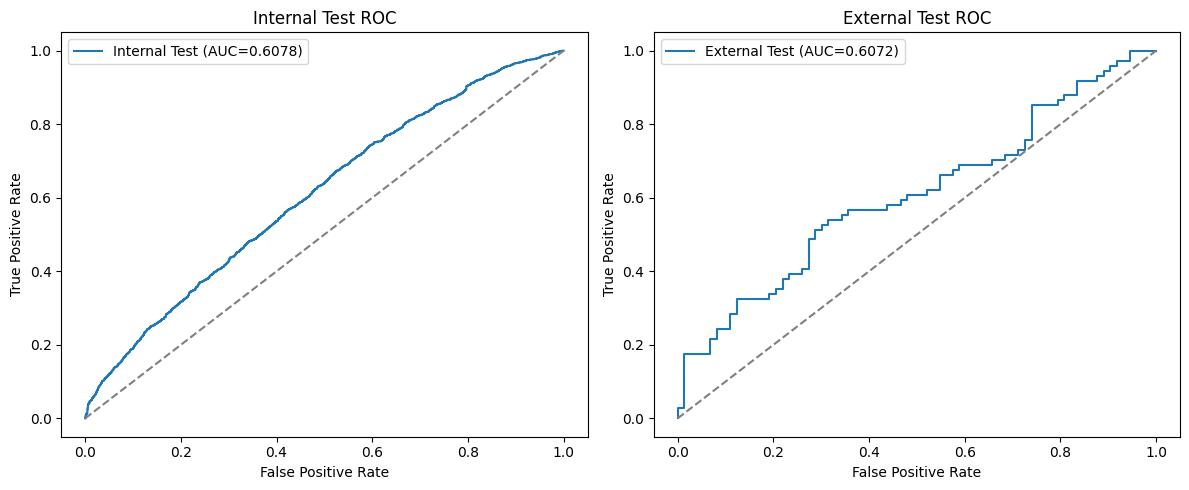

In [20]:
if RUN_TEST_EVALUATION and not RUN_FINAL_TRAINING:
    model = CrossSeqTransformer(dropout=BEST_DROPOUT)
    model.load_state_dict(torch.load("final_model.pt"))
    model = model.to(device)

    # Evaluate on internal test set
    int_preds, int_targets, int_rho, int_auc, int_fpr, int_tpr = evaluate_model(model, int_test_loader, device)
    print(f"Internal Test Set - Spearman rho: {int_rho:.4f}, AUC: {int_auc:.4f}")

    # Evaluate on external test set
    ext_preds, ext_targets, ext_rho, ext_auc, ext_fpr, ext_tpr = evaluate_model(model, ext_test_loader, device)
    print(f"External Test Set - Spearman rho: {ext_rho:.4f}, AUC: {ext_auc:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

    # Internal test ROC
    axes[0].plot(int_fpr, int_tpr, label=f'Internal Test (AUC={int_auc:.4f})')
    axes[0].plot([0,1], [0,1], '--', color='gray')
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title("Internal Test ROC")
    axes[0].legend()

    # External test ROC
    axes[1].plot(ext_fpr, ext_tpr, label=f'External Test (AUC={ext_auc:.4f})')
    axes[1].plot([0,1], [0,1], '--', color='gray')
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title("External Test ROC")
    axes[1].legend()

    plt.tight_layout()
    plt.show()